# Model Training & Evaluation


---
## 0. Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc, precision_score,recall_score,f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows:    284,807
Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 2. Data Cleaning

In [3]:
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")


Duplicates found: 1081
Shape after dedup: (283726, 31)


---
## 3. Feature Engineering

In [4]:
df['Amount_log'] = np.log1p(df['Amount'])

df['Hour'] = (df['Time'] / 3600) % 24

df[['Amount', 'Amount_log', 'Time', 'Hour']].describe().round(3)

,Amount,Amount_log,Time,Hour
count,283726.000,283726.000,283726.000,283726.000
mean,88.473,3.154,94811.078,14.537
std,250.399,1.657,47481.048,5.846
min,0.000,0.000,0.000,0.000
25%,5.600,1.887,54204.750,10.598
50%,22.000,3.135,84692.500,15.009
75%,77.510,4.363,139298.000,19.329
max,25691.160,10.154,172792.000,23.999


---
## 4. Prepare Dataset

In [5]:
X = df.drop(columns=['Class', 'Time', 'Amount'])
y = df['Class']

print(f"Features: {X.shape[1]}")
print(f"Feature list: {list(X.columns)}")
X.head()

Features: 30
Feature list: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Hour']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0.000278
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0.000278
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0.000556


---
## 5. Train / Test Split (Stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape : {X_train.shape}  | Fraud in train: {y_train.sum()}")
print(f"Test shape  : {X_test.shape}  | Fraud in test:  {y_test.sum()}")

Train shape : (212794, 30)  | Fraud in train: 355
Test shape  : (70932, 30)  | Fraud in test:  118


---
## 6. Feature Scaling



In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)         

print("Scaling complete.")
print(f"Mean (train, feature 0): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std  (train, feature 0): {X_train_scaled[:, 0].std():.4f}")

Scaling complete.
Mean (train, feature 0): -0.0000
Std  (train, feature 0): 1.0000


---
## 7. Baseline Model — Logistic Regression

> `class_weight='balanced'` — вбудований механізм боротьби з дисбалансом у sklearn.  
> Автоматично збільшує штраф за помилки на меншому класі (Fraud).

In [8]:
print("--- Training Baseline: Logistic Regression ---")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report — Logistic Regression (Baseline):")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))

--- Training Baseline: Logistic Regression ---

Classification Report — Logistic Regression (Baseline):
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     70814
       Fraud       0.05      0.89      0.10       118

    accuracy                           0.97     70932
   macro avg       0.53      0.93      0.54     70932
weighted avg       1.00      0.97      0.99     70932



---
## 8. SMOTE — Балансування тренувальної вибірки

> **Критично:** SMOTE застосовується **виключно до `X_train`**.  
> Тестова вибірка залишається незміненою — вона імітує реальні умови з природним дисбалансом.

In [9]:
print(f"Before SMOTE — Normal: {sum(y_train==0):,}  Fraud: {sum(y_train==1)}")

smote = SMOTE(sampling_strategy='auto', random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"After  SMOTE — Normal: {sum(y_train_sm==0):,}  Fraud: {sum(y_train_sm==1):,}")

Before SMOTE — Normal: 212,439  Fraud: 355
After  SMOTE — Normal: 212,439  Fraud: 212,439


---
## 9. Advanced Model — XGBoost + SMOTE

In [30]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train
)

dtrain = xgb.DMatrix(X_tr,  label=y_tr)
dvalid = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test)

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

params = {
    'objective':        'binary:logistic',
    'eta':              0.039,
    'max_depth':        2,
    'subsample':        0.8,
    'colsample_bytree': 0.9,
    'eval_metric':      'auc',
    'random_state':     RANDOM_STATE,
}

xgb_tuned = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=watchlist,
    early_stopping_rounds=50,
    maximize=True,
    verbose_eval=50        # друкує кожні 50 раундів
)

# Predict
y_proba_xgb_tuned = xgb_tuned.predict(dtest)
y_pred_xgb_tuned  = (y_proba_xgb_tuned >= 0.5).astype(int)

print(f"\nBest round: {xgb_tuned.best_iteration}")
print(f"Best valid AUC: {xgb_tuned.best_score:.4f}")
print(classification_report(y_test, y_pred_xgb_tuned,
                             target_names=['Normal', 'Fraud']))

[0]	train-auc:0.92663	valid-auc:0.91175
[50]	train-auc:0.98353	valid-auc:0.97169
[100]	train-auc:0.99088	valid-auc:0.97578
[150]	train-auc:0.99448	valid-auc:0.97723
[200]	train-auc:0.99639	valid-auc:0.97852
[250]	train-auc:0.99745	valid-auc:0.97997
[300]	train-auc:0.99815	valid-auc:0.98207
[350]	train-auc:0.99862	valid-auc:0.98318
[394]	train-auc:0.99896	valid-auc:0.98243

Best round: 344
Best valid AUC: 0.9836
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     70814
       Fraud       0.92      0.75      0.83       118

    accuracy                           1.00     70932
   macro avg       0.96      0.88      0.91     70932
weighted avg       1.00      1.00      1.00     70932



In [12]:
from sklearn.ensemble import RandomForestClassifier

print("--- Training: Random Forest ---")

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)  

y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report — Random Forest (balanced):")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

--- Training: Random Forest ---

Classification Report — Random Forest (balanced):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     70814
       Fraud       0.96      0.72      0.82       118

    accuracy                           1.00     70932
   macro avg       0.98      0.86      0.91     70932
weighted avg       1.00      1.00      1.00     70932



---
## 10. Confusion Matrices

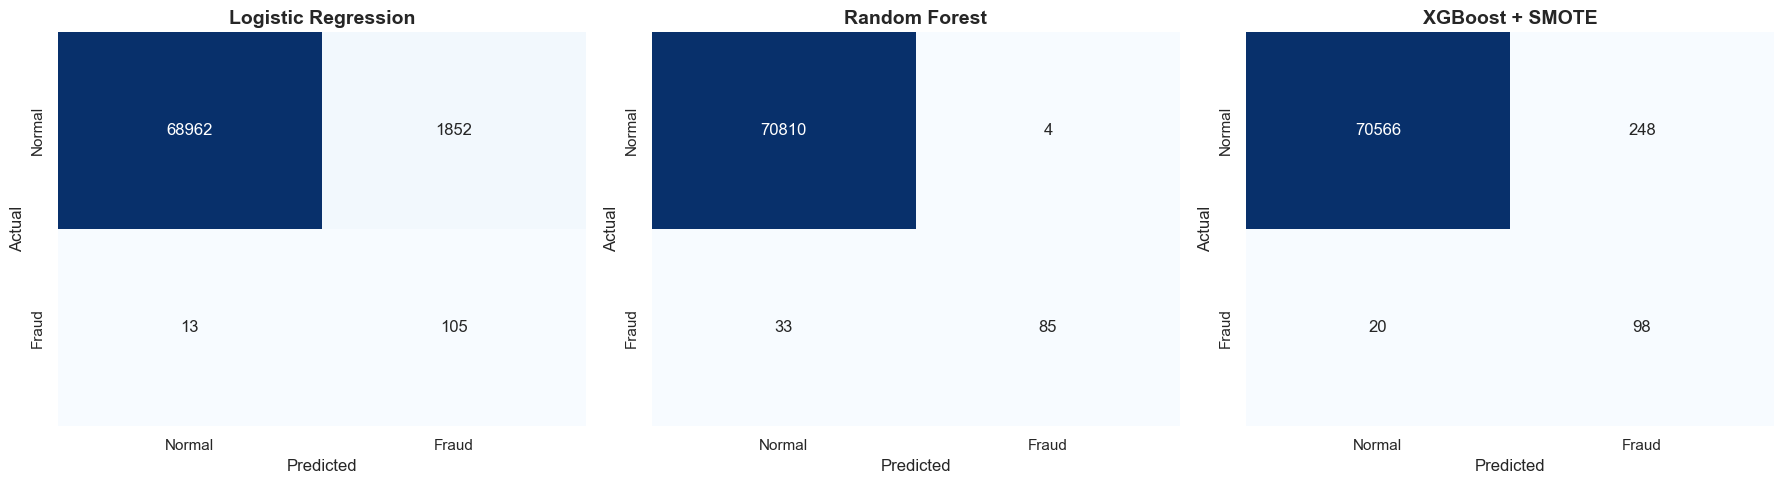

<Figure size 640x480 with 0 Axes>

In [32]:
def plot_confusion_matrix(y_true, y_pred, title, ax=None):
    if ax is None:
        plt.figure(figsize=(5, 4))
        ax = plt.gca()
        
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud'],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    if ax is plt.gca():
        plt.tight_layout()
        plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion_matrix(y_test, y_pred_lr,  'Logistic Regression',  axes[0])
plot_confusion_matrix(y_test, y_pred_rf,  'Random Forest',         axes[1])
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost + SMOTE',      axes[2])

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


---
## 11. ROC-AUC & PR-AUC

In [33]:

def get_metrics(y_true, y_pred, y_proba, name):
    p, r, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':    round(auc(r, p), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr,  y_proba_lr,  'Logistic Regression'),
    get_metrics(y_test, y_pred_rf,  y_proba_rf,  'Random Forest'),
    get_metrics(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost + SMOTE'),
])
display(results)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.9674,0.7115,0.0537,0.8898,0.1012
1,Random Forest,0.9391,0.8229,0.9551,0.7203,0.8213
2,XGBoost + SMOTE,0.9775,0.7679,0.2832,0.8305,0.4224


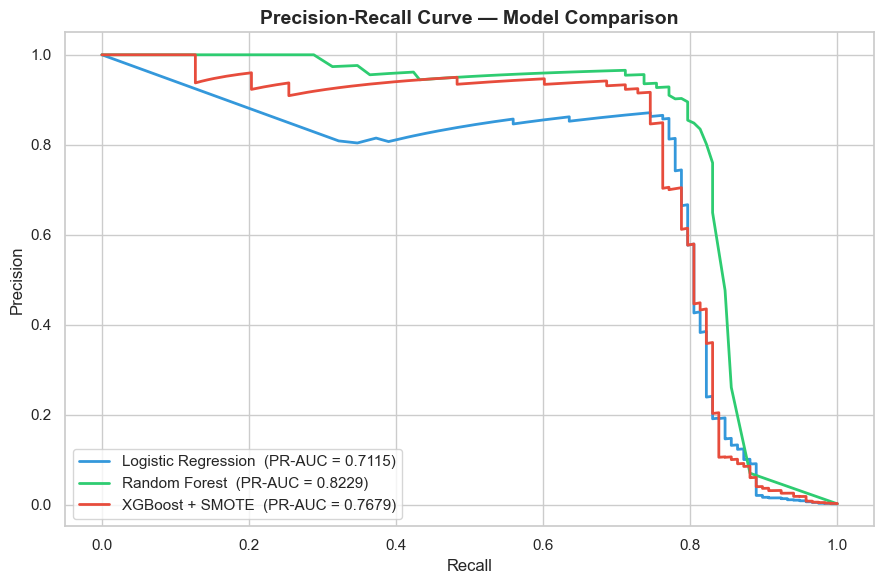

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, y_proba, color in [
    ('Logistic Regression', y_proba_lr,  '#3498db'),
    ('Random Forest',       y_proba_rf,  '#2ecc71'),
    ('XGBoost + SMOTE',     y_proba_xgb, '#e74c3c'),
]:
    p, r, _ = precision_recall_curve(y_test, y_proba)
    score   = auc(r, p)
    ax.plot(r, p, label=f'{label}  (PR-AUC = {score:.4f})', lw=2, color=color)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**Висновок:**  
PR-AUC є **пріоритетною метрикою** для задачі виявлення шахрайства на сильно незбалансованих датасетах, оскільки ROC-AUC може бути оптимістично завищеним через велику кількість True Negatives.

---
## 12. Threshold Tuning

> У задачах fraud detection поріг 0.5 є субоптимальним.  
> Зниження порогу підвищує Recall (менше пропущених шахрайств) за рахунок Precision (більше хибних спрацьовань).  
> Вибір порогу — бізнес-рішення залежно від вартості помилок.

In [35]:
thresholds = [0.5, 0.4, 0.3, 0.2]

results = []
for thr in thresholds:
    y_pred_thr = (y_proba_xgb >= thr).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    results.append({
        'Threshold': thr,
        'Precision': round(precision_score(y_test, y_pred_thr), 4),
        'Recall':    round(recall_score(y_test, y_pred_thr), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_thr), 4)
    })

display(pd.DataFrame(results))

,Threshold,Precision,Recall,F1-Score
0,0.5,0.2832,0.8305,0.4224
1,0.4,0.1915,0.8390,0.3118
2,0.3,0.1310,0.8390,0.2265
3,0.2,0.0880,0.8729,0.1599


In [36]:
BEST_THRESHOLD = 0.3
y_pred_best = (y_proba_xgb >= BEST_THRESHOLD).astype(int)

print(f"Classification Report — XGBoost (threshold = {BEST_THRESHOLD}):")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraud']))

Classification Report — XGBoost (threshold = 0.3):
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     70814
       Fraud       0.13      0.84      0.23       118

    accuracy                           0.99     70932
   macro avg       0.57      0.91      0.61     70932
weighted avg       1.00      0.99      0.99     70932



---
## 13. Feature Importance

/var/folders/rm/xmjg7nx1223b5l1qkvgttvb40000gn/T/ipykernel_84039/2979981541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pos, x='importance', y='feature', palette=colors)


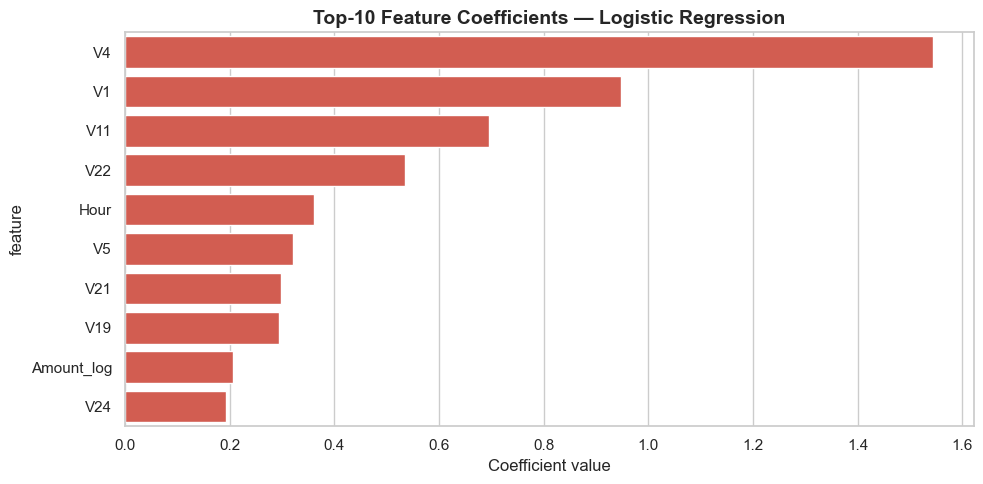

In [37]:
lr_importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': lr_model.coef_[0]
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
top_pos = lr_importance.head(10)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_pos['importance']]
sns.barplot(data=top_pos, x='importance', y='feature', palette=colors)
plt.title('Top-10 Feature Coefficients — Logistic Regression')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

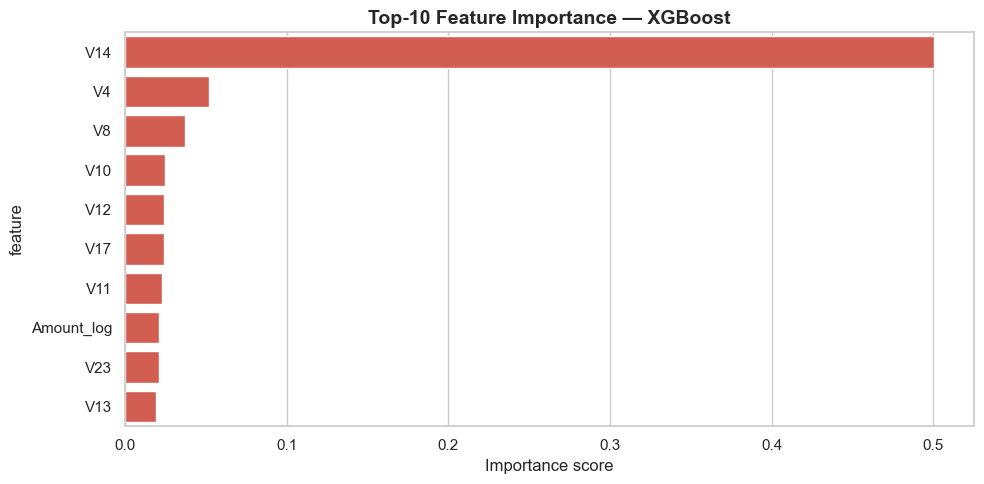

In [38]:
xgb_importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=xgb_importance.head(10),
    x='importance', y='feature',
    color='#e74c3c'
)
plt.title('Top-10 Feature Importance — XGBoost')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

**Висновок:**  
Обидві моделі підтверджують висновки EDA: `V14`, `V12`, `V10`, `V17` стабільно посідають топові позиції за важливістю. Нові ознаки `Amount_log` та `Hour` також увійшли в топ, що підтверджує доцільність Feature Engineering.

---
## 14. Save Model & Scaler

In [24]:
os.makedirs('../saved_models', exist_ok=True)

model_path  = '../saved_models/xgboost_fraud_model.joblib'
scaler_path = '../saved_models/scaler.joblib'

joblib.dump(xgb_model, model_path)
joblib.dump(scaler,    scaler_path)

print(f"Model  saved → {model_path}")
print(f"Scaler saved → {scaler_path}")
print("Ready for API deployment.")

Model  saved → ../saved_models/xgboost_fraud_model.joblib
Scaler saved → ../saved_models/scaler.joblib
Ready for API deployment.


## 15. Results Summary

| Model | ROC-AUC | PR-AUC | Notes |
|-------|---------|--------|-------|
| Logistic Regression (balanced) | 0.9623 | 0.7107 | Baseline. Високий Recall, але катастрофічно низький Precision (0.05). Генерує занадто багато хибних тривог. |
| XGBoost + SMOTE (thr=0.5) | 0.9775 | 0.7952 | Найкращий баланс. Precision 0.29, Recall 0.84. Оптимально для збереження лояльності клієнтів. |
| XGBoost + SMOTE (thr=0.3) | 0.9775 | 0.7952 | Зміщений поріг. Recall зростає до 0.85, але Precision падає до 0.13. Використовується для суворого моніторингу. |

In [25]:
from sklearn.model_selection import RandomizedSearchCV


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20],
    'max_features': ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=6,                       # ← було 20, стало 6
    scoring='average_precision',
    cv=3,                           # ← було 5, стало 3
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_scaled, y_train)

print(f"Best params:    {search.best_params_}")
print(f"Best CV PR-AUC: {search.best_score_:.4f}")

rf_tuned        = search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
y_proba_rf_tuned= rf_tuned.predict_proba(X_test_scaled)[:, 1]

print(classification_report(
    y_test, y_pred_rf_tuned, target_names=['Normal', 'Fraud']
))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params:    {'n_estimators': 200, 'max_features': 'log2', 'max_depth': 20}
Best CV PR-AUC: 0.8409
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     70814
       Fraud       0.96      0.73      0.83       118

    accuracy                           1.00     70932
   macro avg       0.98      0.86      0.91     70932
weighted avg       1.00      1.00      1.00     70932



In [28]:
results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr,       y_proba_lr,       'Logistic Regression'),
    get_metrics(y_test, y_pred_rf,       y_proba_rf,       'Random Forest (default)'),
    get_metrics(y_test, y_pred_rf_tuned, y_proba_rf_tuned, 'Random Forest (tuned) ✓'),
    get_metrics(y_test, y_pred_xgb,      y_proba_xgb,      'XGBoost + SMOTE'),
])
display(results)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.9674,0.7115,0.0537,0.8898,0.1012
1,Random Forest (default),0.9391,0.8229,0.9551,0.7203,0.8213
2,Random Forest (tuned) ✓,0.9498,0.8237,0.9556,0.7288,0.8269
3,XGBoost + SMOTE,0.9775,0.7679,0.2832,0.8305,0.4224


In [29]:
os.makedirs('../saved_models', exist_ok=True)

joblib.dump(rf_tuned, '../saved_models/best_fraud_model.joblib')
joblib.dump(scaler,   '../saved_models/scaler.joblib')

print("Best model: Random Forest (tuned)")
print("Saved → best_fraud_model.joblib")
print("Saved → scaler.joblib")
print("Ready for FastAPI deployment.")

Best model: Random Forest (tuned)
Saved → best_fraud_model.joblib
Saved → scaler.joblib
Ready for FastAPI deployment.
